# Music by Instrument — Inference

Classify the dominant musical instrument(s) in a track using [`Bhaveen/Musical-Instrument-Classification`](https://huggingface.co/Bhaveen/Musical-Instrument-Classification), a `facebook/wav2vec2-base-960h` fine-tuned for **9-class instrument classification**.

The model expects mono audio resampled to **16 kHz**, in **3-second** clips (48 000 samples). Tracks here are full songs, so we split each track into 3-second windows, classify every window, and average the probabilities to get a per-track instrument profile.

**Instrument classes:** Acoustic Guitar, Bass Guitar, Drum Set, Electric Guitar, Flute, Hi-Hats, Keyboard, Trumpet, Violin.

**Inference tracks (compared below) — same files as the emotion notebook:**
- `My Drive/google_colab/Nero - Blame You.mp3`
- `My Drive/google_colab/The Cardigans - My Favourite Game (Ozma bootleg).mp3`

## 1. Install dependencies

In [1]:
!pip install -q transformers torch torchaudio librosa

## 2. Mount Google Drive

After mounting, `My Drive` is available at `/content/drive/MyDrive`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

AUDIO_DIR = '/content/drive/MyDrive/google_colab'
AUDIO_PATHS = [
    f'{AUDIO_DIR}/Nero - Blame You.mp3',
    f'{AUDIO_DIR}/The Cardigans - My Favourite Game (Ozma bootleg).mp3',
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Load the model and processor

In [3]:
import torch
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

MODEL_ID = 'Bhaveen/Musical-Instrument-Classification'

device = 'cuda' if torch.cuda.is_available() else 'cpu'

extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID)
model = AutoModelForAudioClassification.from_pretrained(MODEL_ID).to(device).eval()

# Instrument labels come straight from the model config.
INSTRUMENT_LABELS = [model.config.id2label[i] for i in range(model.config.num_labels)]

# Sampling rate the feature extractor expects (16 kHz for wav2vec2)
TARGET_SR = extractor.sampling_rate
# The model was trained on fixed 3-second clips (48 000 samples).
CLIP_SECONDS = 3
CLIP_SAMPLES = TARGET_SR * CLIP_SECONDS

print('Target sampling rate:', TARGET_SR)
print('Clip length:', CLIP_SECONDS, 's', f'({CLIP_SAMPLES} samples)')
print('Instrument labels:', INSTRUMENT_LABELS)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.51k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Target sampling rate: 16000
Clip length: 3 s (48000 samples)
Instrument labels: ['Acoustic_Guitar', 'Bass_Guitar', 'Drum_set', 'Electro_Guitar', 'flute', 'Hi_Hats', 'Keyboard', 'Trumpet', 'Violin']


## 4. Inference helper

Load a track (mono, 16 kHz), split it into non-overlapping 3-second windows, run
the model on every window, and **average the softmax probabilities** across
windows. The result is a per-track instrument distribution plus the per-window
top predictions (so we can see how the dominant instrument shifts over time).

In [4]:
import os
import numpy as np
import librosa


def classify(path, batch_size=32):
    """Return (mean_probs, window_top_ids, duration_seconds) for one audio file.

    The track is chopped into non-overlapping 3-second windows; the last,
    shorter window is zero-padded to the full clip length.
    """
    waveform, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    duration = len(waveform) / sr

    # Split into 3-second windows, padding the final partial window.
    windows = []
    for start in range(0, len(waveform), CLIP_SAMPLES):
        clip = waveform[start:start + CLIP_SAMPLES]
        if len(clip) < CLIP_SAMPLES:
            clip = np.pad(clip, (0, CLIP_SAMPLES - len(clip)))
        windows.append(clip)

    all_probs = []
    for i in range(0, len(windows), batch_size):
        batch = windows[i:i + batch_size]
        inputs = extractor(batch, sampling_rate=TARGET_SR, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
        all_probs.append(torch.softmax(logits, dim=-1).cpu())

    probs = torch.cat(all_probs, dim=0)        # (n_windows, n_labels)
    mean_probs = probs.mean(dim=0)             # (n_labels,)
    window_top_ids = probs.argmax(dim=-1)      # (n_windows,)
    return mean_probs, window_top_ids, duration


# Run inference on every track up front.
results = {}
window_preds = {}
for path in AUDIO_PATHS:
    name = os.path.splitext(os.path.basename(path))[0]
    mean_probs, top_ids, duration = classify(path)
    results[name] = mean_probs
    window_preds[name] = top_ids
    print(f'{name} — {duration:.1f}s ({len(top_ids)} windows)')

Nero - Blame You — 200.5s (67 windows)
The Cardigans - My Favourite Game (Ozma bootleg) — 270.2s (91 windows)


## 5. Top prediction per track

The single most likely instrument (averaged over the whole track) plus the
share of 3-second windows where it was the top pick.

In [5]:
for name, probs in results.items():
    top_id = int(probs.argmax())
    top_ids = window_preds[name]
    window_share = (top_ids == top_id).float().mean().item()
    print(f'{name}')
    print(f'  Predicted instrument: {INSTRUMENT_LABELS[top_id]} '
          f'({probs[top_id].item():.2%} mean prob, '
          f'top in {window_share:.0%} of windows)\n')

Nero - Blame You
  Predicted instrument: Hi_Hats (18.40% mean prob, top in 54% of windows)

The Cardigans - My Favourite Game (Ozma bootleg)
  Predicted instrument: Hi_Hats (21.63% mean prob, top in 70% of windows)



## 6. Side-by-side comparison

Full per-instrument mean probabilities for both tracks, sorted by the first track's scores.

In [6]:
import pandas as pd

comparison = pd.DataFrame(
    {name: [probs[i].item() for i in range(len(INSTRUMENT_LABELS))]
     for name, probs in results.items()},
    index=INSTRUMENT_LABELS,
)
comparison.index.name = 'instrument'

# Sort by the first track's probability for easy reading.
comparison = comparison.sort_values(by=comparison.columns[0], ascending=False)

# Show as percentages.
(comparison * 100).round(2).style.format('{:.2f}%')

,Nero - Blame You,The Cardigans - My Favourite Game (Ozma bootleg)
instrument,,
Hi_Hats,18.40%,21.63%
Trumpet,16.73%,18.94%
Acoustic_Guitar,15.25%,11.53%
Violin,13.66%,12.85%
Electro_Guitar,13.04%,9.63%
Keyboard,6.44%,7.34%
flute,5.89%,6.54%
Drum_set,5.60%,6.29%
Bass_Guitar,4.99%,5.23%


## 7. Instrument timeline

How the per-window top instrument changes over the course of each track — a quick
look at which instruments the model latches onto in different sections.

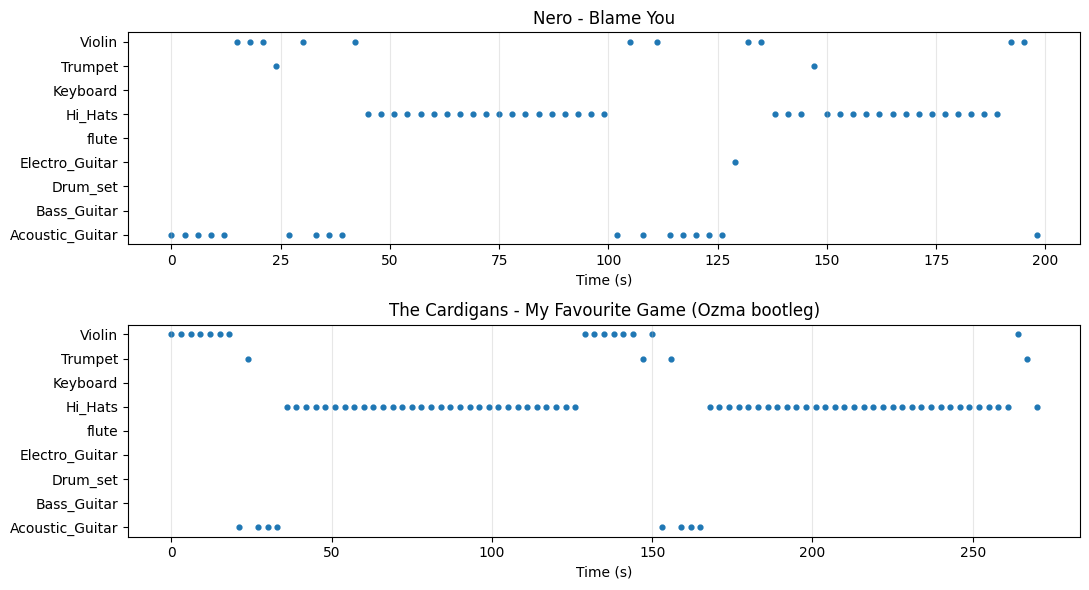

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(window_preds), 1, figsize=(11, 3 * len(window_preds)),
                         squeeze=False)
for ax, (name, top_ids) in zip(axes[:, 0], window_preds.items()):
    times = np.arange(len(top_ids)) * CLIP_SECONDS
    ax.scatter(times, top_ids.numpy(), s=12)
    ax.set_yticks(range(len(INSTRUMENT_LABELS)))
    ax.set_yticklabels(INSTRUMENT_LABELS)
    ax.set_xlabel('Time (s)')
    ax.set_title(name)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()